In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *

In [2]:
N = 6
wd = 0.6365091993031
wm = 1.0
freq_dis = 0.00
indv_qubit = False
t_max = 200
tlist = np.linspace(0, t_max, 400)
reals = 300
rand = True
z_ham = False
dis = 0.3

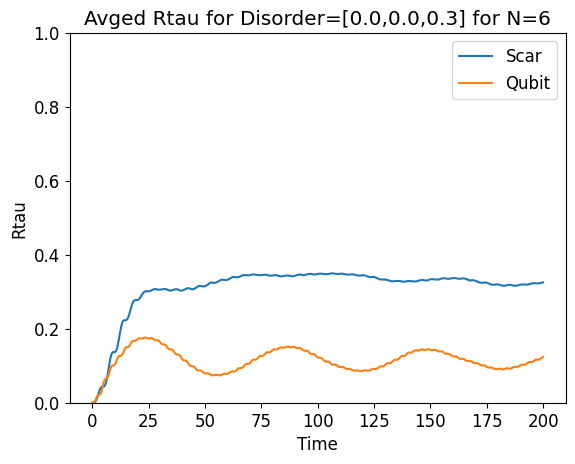

C:\Users\idden\AppData\Local\Temp\ipykernel_26992\1656540985.py:48: RuntimeWarning: invalid value encountered in divide
  plt.plot(tlist, xfull_scar / xfull_qubit)


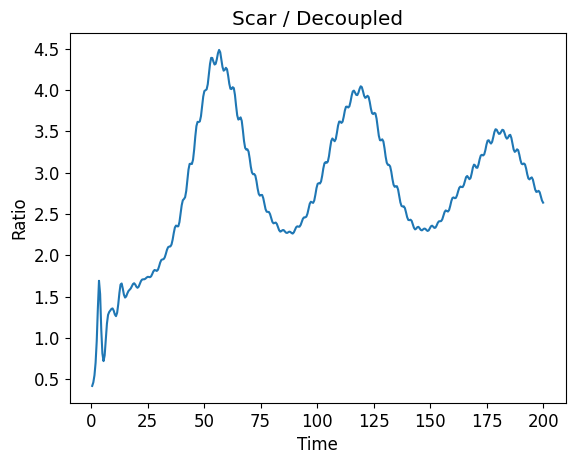

In [3]:
dz = 0.0
dy = 0.0
dx = dis

args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}

H0_clean, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)

full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = getDisorderedScarHam(H0_clean, N, basisList, ham_disorder=[dz, dy, dx])
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

xfull_scar = full_scar / reals

qH0_clean, qH1, qeigenvalues, qeigenstates = get_qubit_ham(N)

full_qubit = 0
for _ in range(reals):
    qH0, qeigenvalues, qeigenstates = getDisorderedQubitHam(qH0_clean, N, ham_disorder=[dz, dy, dx])
    qbandwidth = qeigenvalues[-1] - qeigenvalues[0]

    qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
    qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
    Rtau_qubit = np.array(np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qbandwidth)
    full_qubit += Rtau_qubit

xfull_qubit = full_qubit / reals

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, xfull_scar, label="Scar")
plt.plot(tlist, xfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()

plt.title("Scar / Decoupled")
plt.xlabel("Time")
plt.ylabel("Ratio")
plt.plot(tlist, xfull_scar / xfull_qubit)
plt.show()

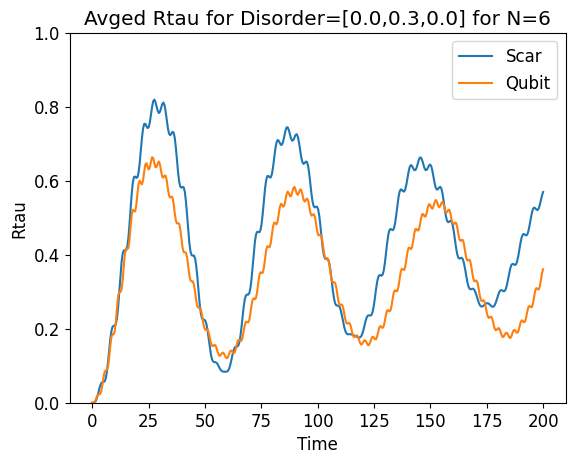

C:\Users\idden\AppData\Local\Temp\ipykernel_26992\2354323409.py:48: RuntimeWarning: invalid value encountered in divide
  plt.plot(tlist, yfull_scar / yfull_qubit)


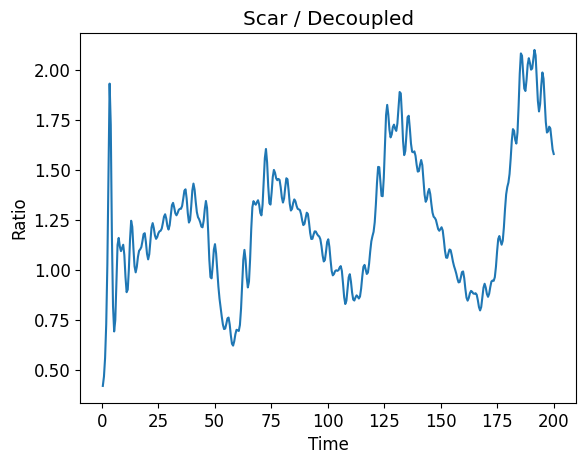

In [ ]:
dz = 0.0
dy = dis
dx = 0.0

args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}

H0_clean, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)

full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = getDisorderedScarHam(H0_clean, N, basisList, ham_disorder=[dz, dy, dx])
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

yfull_scar = full_scar / reals

qH0_clean, qH1, qeigenvalues, qeigenstates = get_qubit_ham(N)

full_qubit = 0
for _ in range(reals):
    qH0, qeigenvalues, qeigenstates = getDisorderedQubitHam(qH0_clean, N, ham_disorder=[dz, dy, dx])
    qbandwidth = qeigenvalues[-1] - qeigenvalues[0]

    qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
    qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
    Rtau_qubit = np.array(np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qbandwidth)
    full_qubit += Rtau_qubit

yfull_qubit = full_qubit / reals

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, yfull_scar, label="Scar")
plt.plot(tlist, yfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()

plt.title("Scar / Decoupled")
plt.xlabel("Time")
plt.ylabel("Ratio")
plt.plot(tlist, yfull_scar / yfull_qubit)
plt.show()

[0.29794942 0.21132017 0.23143812 0.21178588 0.11117104 0.12111035]
[-0.29813027 -0.29234965 -0.13753105  0.24779429 -0.26703481  0.19327849]
[-0.09677737 -0.09492655 -0.21461367  0.09540389  0.24420109 -0.27362842]
[ 0.10188617 -0.17835968  0.22078216  0.01400015  0.07377531 -0.16064318]
[-0.10485996 -0.23127964  0.28683218  0.10610738  0.15585679  0.24142996]
[-0.07466747  0.16531079  0.16367903 -0.29935221 -0.17046062  0.12219049]
[-0.17445713  0.04221745 -0.15665062  0.08663065 -0.09222145 -0.05627023]
[-0.28472857  0.10478282  0.14020344  0.15682827  0.22870554 -0.056324  ]
[ 0.29184843  0.18525594 -0.18634958  0.07718233 -0.07053476 -0.18448081]
[-0.05520369 -0.03528986 -0.01324541  0.05216026  0.10600428 -0.19180082]
[-0.00911959  0.10793426  0.07338602  0.02574082  0.02442206 -0.29317986]
[-0.00796384  0.25509978 -0.21885119  0.20880017 -0.16817573  0.15713343]
[-0.2211164   0.29988172 -0.01720408 -0.16856277 -0.29995612  0.15139718]
[-0.12880596 -0.18519023 -0.17765137  0.1545

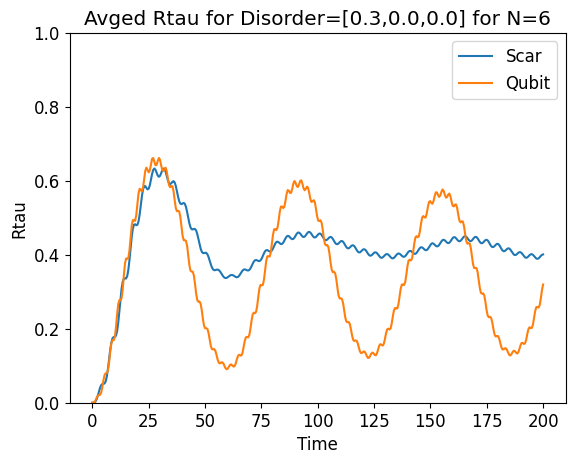

C:\Users\idden\AppData\Local\Temp\ipykernel_26992\3466210723.py:48: RuntimeWarning: invalid value encountered in divide
  plt.plot(tlist, zfull_scar / zfull_qubit)


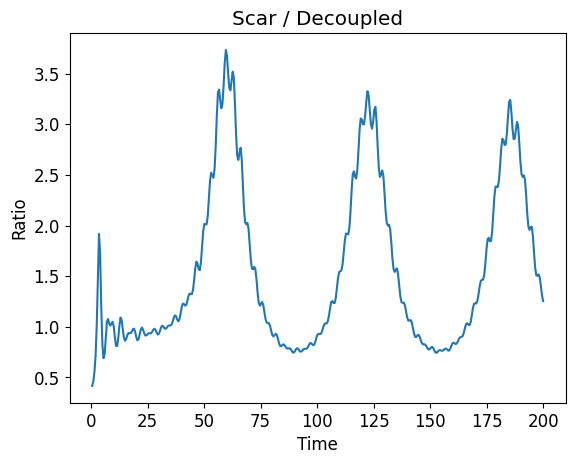

In [5]:
dz = dis
dy = 0.0
dx = 0.0

args = {"A": 0.1, "omega": wd}
qargs = {"A": 0.1, "omega": wm}

H0_clean, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)

full_scar = 0
for _ in range(reals):
    H0, eigenvalues, eigenstates = getDisorderedScarHam(H0_clean, N, basisList, ham_disorder=[dz, dy, dx])
    bandwidth = eigenvalues[-1] - eigenvalues[0]

    H = qt.QobjEvo([H0, [H1, coeff]], args=args)
    psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
    Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    full_scar += Rtau_scar

zfull_scar = full_scar / reals

qH0_clean, qH1, qeigenvalues, qeigenstates = get_qubit_ham(N)

full_qubit = 0
for _ in range(reals):
    qH0, qeigenvalues, qeigenstates = getDisorderedQubitHam(qH0_clean, N, ham_disorder=[dz, dy, dx])
    qbandwidth = qeigenvalues[-1] - qeigenvalues[0]

    qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
    qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist, e_ops=[qH0])
    Rtau_qubit = np.array(np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qbandwidth)
    full_qubit += Rtau_qubit

zfull_qubit = full_qubit / reals

plt.title(f"Avged Rtau for Disorder=[{dz},{dy},{dx}] for N={N}")
plt.xlabel("Time")
plt.ylabel("Rtau")
plt.plot(tlist, zfull_scar, label="Scar")
plt.plot(tlist, zfull_qubit, label="Qubit")
plt.legend()
plt.ylim(0, 1)
plt.show()

plt.title("Scar / Decoupled")
plt.xlabel("Time")
plt.ylabel("Ratio")
plt.plot(tlist, zfull_scar / zfull_qubit)
plt.show()

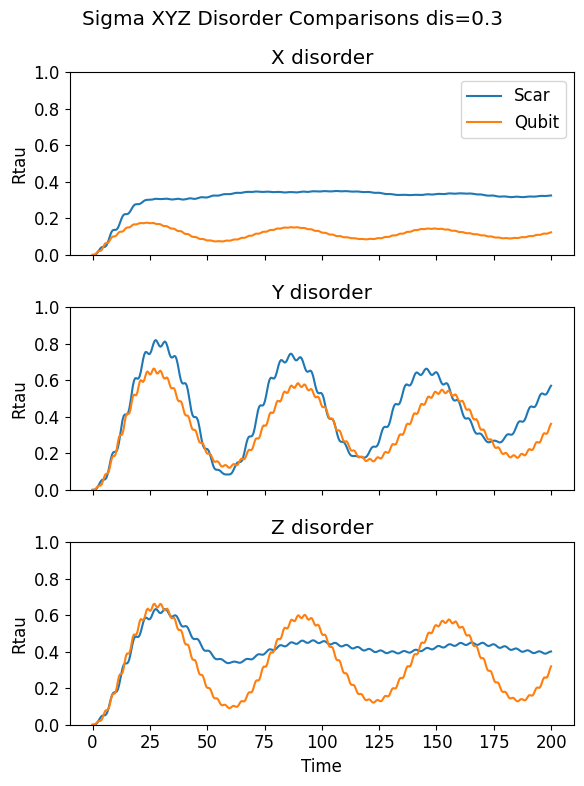

<Figure size 640x480 with 0 Axes>

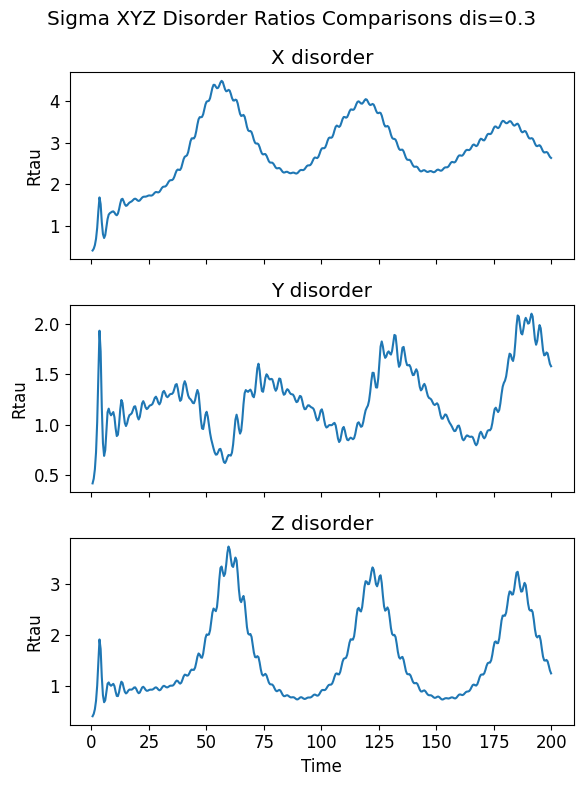

In [6]:
fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
fig.suptitle("Sigma XYZ Disorder Comparisons dis=0.3")

axs[0].plot(tlist, xfull_scar, label="Scar")
axs[0].plot(tlist, xfull_qubit, label="Qubit")
axs[0].set_title("X disorder")
axs[0].set_ylabel("Rtau")
axs[0].legend()

axs[1].plot(tlist, yfull_scar, label="Scar")
axs[1].plot(tlist, yfull_qubit, label="Qubit")
axs[1].set_title("Y disorder")
axs[1].set_ylabel("Rtau")

axs[2].plot(tlist, zfull_scar, label="Scar")
axs[2].plot(tlist, zfull_qubit, label="Qubit")
axs[2].set_title("Z disorder")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Rtau")

axs[0].set_ylim(0, 1)
axs[1].set_ylim(0, 1)
axs[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
fig.suptitle("Sigma XYZ Disorder Ratios Comparisons dis=0.3")

axs[0].plot(tlist[1:], xfull_scar[1:] / xfull_qubit[1:])
axs[0].set_title("X disorder")
axs[0].set_ylabel("Rtau")

axs[1].plot(tlist[1:], yfull_scar[1:] / yfull_qubit[1:])
axs[1].set_title("Y disorder")
axs[1].set_ylabel("Rtau")

axs[2].plot(tlist[1:], zfull_scar[1:] / zfull_qubit[1:])
axs[2].set_title("Z disorder")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Rtau")

plt.tight_layout()
plt.show()